In [25]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Libraries imported successfully!")
print(f"   Random seed set to: {RANDOM_STATE}")

✅ Libraries imported successfully!
   Random seed set to: 42


In [26]:
# Load the dataset with classes from Notebook 02
DATA_PATH = '../processed_data/dataset_with_classes.csv'

# Check if file exists, if not use original and process
if os.path.exists(DATA_PATH):
    print(f"Loading processed dataset from: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
else:
    print("⚠️ Processed dataset not found. Loading original and creating classes...")
    df = pd.read_csv('../dataset_with_all_targets_present.csv')
    
    # Create water quality scores (same as Notebook 02)
    df['chl_a_score'] = 100 - df['chl_a'].rank(pct=True) * 100
    df['tss_score'] = 100 - df['tss'].rank(pct=True) * 100
    df['secchi_score'] = df['secchi'].rank(pct=True) * 100
    df['wq_score'] = (df['chl_a_score'] + df['tss_score'] + df['secchi_score']) / 3
    
    # Create classes based on percentiles
    threshold_poor_moderate = df['wq_score'].quantile(0.33)
    threshold_moderate_good = df['wq_score'].quantile(0.67)
    
    def assign_class(score):
        if score < threshold_poor_moderate:
            return 'Poor'
        elif score < threshold_moderate_good:
            return 'Moderate'
        else:
            return 'Good'
    
    df['water_quality_class'] = df['wq_score'].apply(assign_class)
    df['water_quality_label'] = df['water_quality_class'].map({'Poor': 0, 'Moderate': 1, 'Good': 2})

print(f"\n✅ Dataset loaded successfully!")
print(f"   Records: {len(df):,}")
print(f"   Columns: {len(df.columns)}")

Loading processed dataset from: ../processed_data/dataset_with_classes.csv

✅ Dataset loaded successfully!
   Records: 57,268
   Columns: 51


## 1. Feature Selection Strategy

### 1.1 Feature Categories

| Category | Features | Use? | Reason |
|----------|----------|------|--------|
| **Spectral Bands** | blue, green, red, nir, swir1, swir2 | ✅ YES | Primary predictors |
| **Spectral SDs** | band_sd columns | ✅ YES | Capture pixel heterogeneity |
| **Water Quality Params** | chl_a, tss, secchi | ❌ NO | Used for target definition |
| **Quality Scores** | chl_a_score, tss_score, etc. | ❌ NO | Derived from targets |
| **Satellite Metadata** | sat, pixelCount, clouds, pwater | ⚠️ SOME | Context features |
| **Temporal** | year, month | ⚠️ SOME | Seasonal patterns |
| **Spatial** | lat, long, type | ⚠️ SOME | Geographic context |
| **Identifiers** | SiteID, landsat_id, etc. | ❌ NO | Not predictive |

In [27]:
# Define feature groups
print(f"{'='*60}")
print(f"FEATURE SELECTION")
print(f"{'='*60}")

# Core spectral features (PRIMARY PREDICTORS)
SPECTRAL_BANDS = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
SPECTRAL_SD = ['blue_sd', 'green_sd', 'red_sd', 'nir_sd', 'swir1_sd', 'swir2_sd']

# Satellite metadata features
SATELLITE_FEATURES = ['pixelCount', 'clouds', 'pwater', 'qa']

# Temporal features (for seasonal analysis)
TEMPORAL_FEATURES = ['month']  # Will be encoded

# Categorical features to encode
CATEGORICAL_FEATURES = ['sat', 'type']  # Satellite and water body type

# Target columns (EXCLUDED from features)
TARGET_EXCLUDE = ['chl_a', 'tss', 'secchi', 'chl_a_score', 'tss_score', 'secchi_score', 
                  'wq_score', 'water_quality_class', 'water_quality_label']

# ID/non-predictive columns (EXCLUDED)
ID_EXCLUDE = ['system:index', 'SiteID', 'landsat_id', 'id', 'source', 'wq_pattern',
              'date', 'date_parsed', 'date_only', 'date_unity', 'date_utc', 'time',
              'endtime', 'timediff', 'lat', 'long', '.geo', 'TZID', 'path', 'row', 
              'p_sand', 'year']

print(f"\n📊 PRIMARY FEATURES (Spectral):")
print(f"   Bands: {SPECTRAL_BANDS}")
print(f"   Standard Deviations: {SPECTRAL_SD}")

print(f"\n📊 SECONDARY FEATURES (Metadata):")
print(f"   Satellite: {SATELLITE_FEATURES}")
print(f"   Categorical: {CATEGORICAL_FEATURES}")
print(f"   Temporal: {TEMPORAL_FEATURES}")

print(f"\n🚫 EXCLUDED (Targets & IDs):")
print(f"   {len(TARGET_EXCLUDE) + len(ID_EXCLUDE)} columns excluded")

FEATURE SELECTION

📊 PRIMARY FEATURES (Spectral):
   Bands: ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
   Standard Deviations: ['blue_sd', 'green_sd', 'red_sd', 'nir_sd', 'swir1_sd', 'swir2_sd']

📊 SECONDARY FEATURES (Metadata):
   Satellite: ['pixelCount', 'clouds', 'pwater', 'qa']
   Categorical: ['sat', 'type']
   Temporal: ['month']

🚫 EXCLUDED (Targets & IDs):
   31 columns excluded


## 2. Feature Engineering: Spectral Indices

### 2.1 Common Water-Related Spectral Indices

Spectral indices are ratios/combinations of bands that highlight specific features:

| Index | Formula | Purpose |
|-------|---------|----------|
| **NDWI** | (green - nir) / (green + nir) | Water detection |
| **NDVI** | (nir - red) / (nir + red) | Vegetation/algae |
| **NDTI** | (red - green) / (red + green) | Turbidity index |
| **BR** | blue / red | Blue-Red ratio |
| **GR** | green / red | Green-Red ratio |
| **NBR** | nir / blue | NIR-Blue ratio |

In [28]:
# Create spectral indices
print(f"{'='*60}")
print(f"CREATING SPECTRAL INDICES")
print(f"{'='*60}")

# Function to safely compute normalized difference
def normalized_difference(b1, b2):
    """Compute (b1 - b2) / (b1 + b2) with zero handling"""
    sum_bands = b1 + b2
    # Avoid division by zero
    return np.where(sum_bands != 0, (b1 - b2) / sum_bands, 0)

# Function to safely compute ratio
def band_ratio(b1, b2, clip_max=10):
    """Compute b1 / b2 with zero handling and clipping"""
    ratio = np.where(b2 != 0, b1 / b2, 0)
    return np.clip(ratio, -clip_max, clip_max)

# Normalized Difference Water Index (NDWI)
df['NDWI'] = normalized_difference(df['green'], df['nir'])
print("   ✅ NDWI = (green - nir) / (green + nir)")

# Normalized Difference Vegetation Index (NDVI)
# Can indicate algal presence in water
df['NDVI'] = normalized_difference(df['nir'], df['red'])
print("   ✅ NDVI = (nir - red) / (nir + red)")

# Normalized Difference Turbidity Index (NDTI)
df['NDTI'] = normalized_difference(df['red'], df['green'])
print("   ✅ NDTI = (red - green) / (red + green)")

# Blue-Red Ratio (BR) - sensitive to chlorophyll
df['BR'] = band_ratio(df['blue'], df['red'])
print("   ✅ BR = blue / red")

# Green-Red Ratio (GR) - sensitive to turbidity
df['GR'] = band_ratio(df['green'], df['red'])
print("   ✅ GR = green / red")

# NIR-Blue Ratio (NBR) 
df['NBR'] = band_ratio(df['nir'], df['blue'])
print("   ✅ NBR = nir / blue")

# Blue-Green Ratio - indicator of water clarity
df['BG'] = band_ratio(df['blue'], df['green'])
print("   ✅ BG = blue / green")

# SWIR-NIR difference - moisture content
df['MNDWI'] = normalized_difference(df['green'], df['swir1'])
print("   ✅ MNDWI = (green - swir1) / (green + swir1)")

SPECTRAL_INDICES = ['NDWI', 'NDVI', 'NDTI', 'BR', 'GR', 'NBR', 'BG', 'MNDWI']

print(f"\n✅ Created {len(SPECTRAL_INDICES)} spectral indices!")

CREATING SPECTRAL INDICES
   ✅ NDWI = (green - nir) / (green + nir)
   ✅ NDVI = (nir - red) / (nir + red)
   ✅ NDTI = (red - green) / (red + green)
   ✅ BR = blue / red
   ✅ GR = green / red
   ✅ NBR = nir / blue
   ✅ BG = blue / green
   ✅ MNDWI = (green - swir1) / (green + swir1)

✅ Created 8 spectral indices!


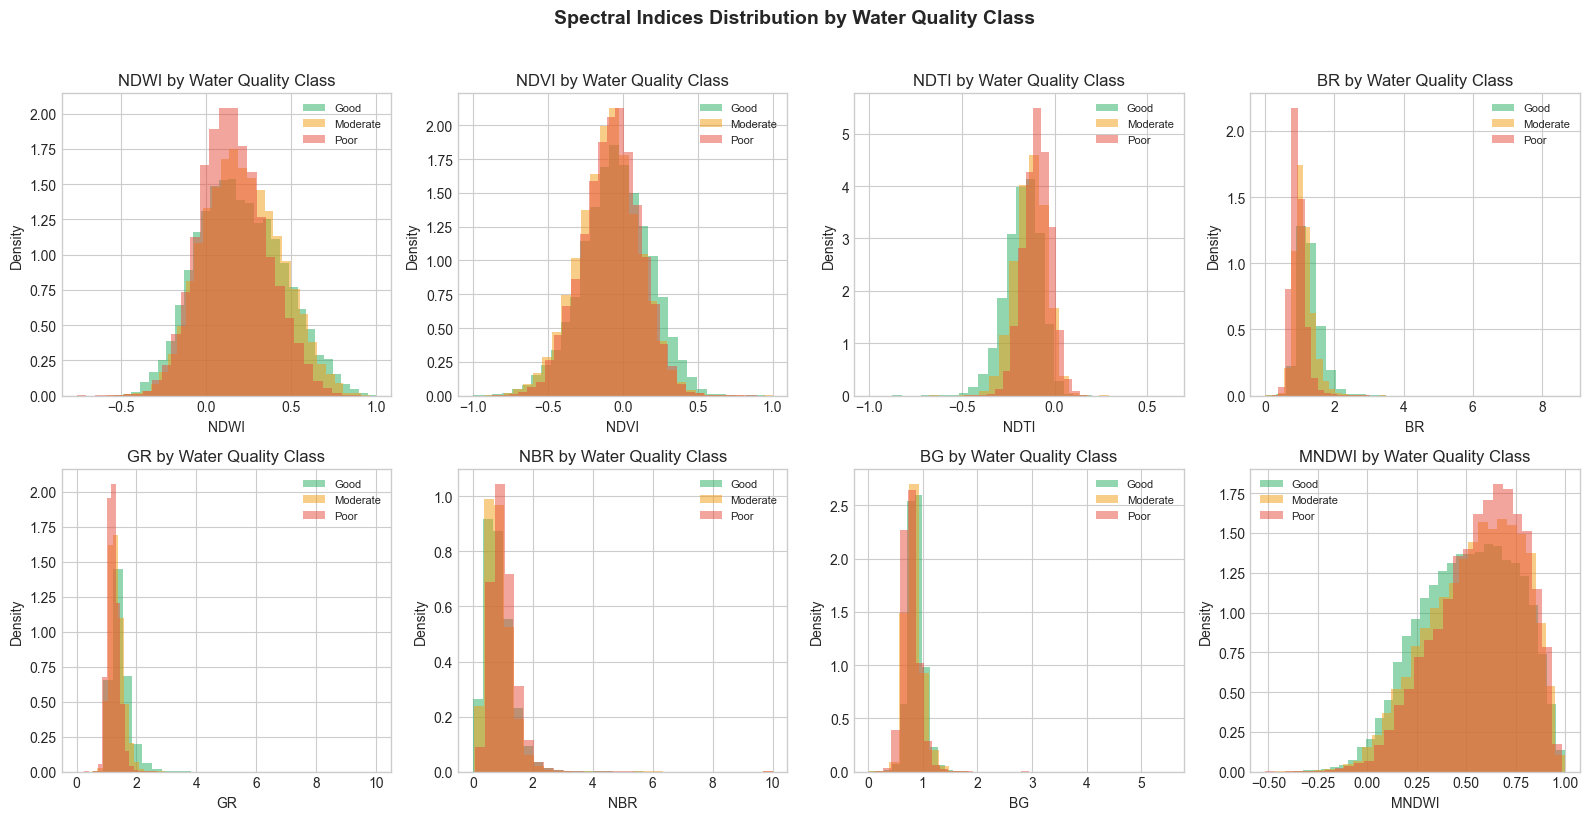

In [29]:
# Visualize spectral indices by class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

class_order = ['Good', 'Moderate', 'Poor']
colors = {'Good': '#27ae60', 'Moderate': '#f39c12', 'Poor': '#e74c3c'}

for i, idx in enumerate(SPECTRAL_INDICES):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    for class_name in class_order:
        data = df[df['water_quality_class'] == class_name][idx].dropna()
        ax.hist(data, bins=30, alpha=0.5, label=class_name, color=colors[class_name], density=True)
    
    ax.set_xlabel(idx)
    ax.set_ylabel('Density')
    ax.set_title(f'{idx} by Water Quality Class')
    ax.legend(fontsize=8)

plt.suptitle('Spectral Indices Distribution by Water Quality Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Compile Feature Set

### 3.1 Final Feature List

Combining all selected features for the model.

In [30]:
# Compile final feature list
print(f"{'='*60}")
print(f"COMPILING FEATURE SET")
print(f"{'='*60}")

# All numeric features
NUMERIC_FEATURES = SPECTRAL_BANDS + SPECTRAL_SD + SPECTRAL_INDICES + SATELLITE_FEATURES

# Check which features exist in the dataframe
available_numeric = [f for f in NUMERIC_FEATURES if f in df.columns]
missing_numeric = [f for f in NUMERIC_FEATURES if f not in df.columns]

print(f"\n📊 NUMERIC FEATURES ({len(available_numeric)} available):")
for i, f in enumerate(available_numeric, 1):
    print(f"   {i:2d}. {f}")

if missing_numeric:
    print(f"\n⚠️ Missing features: {missing_numeric}")

# Categorical features
print(f"\n📊 CATEGORICAL FEATURES ({len(CATEGORICAL_FEATURES)}):")
for f in CATEGORICAL_FEATURES:
    n_unique = df[f].nunique() if f in df.columns else 'N/A'
    print(f"   • {f}: {n_unique} unique values")

print(f"\n📊 TEMPORAL FEATURES ({len(TEMPORAL_FEATURES)}):")
for f in TEMPORAL_FEATURES:
    print(f"   • {f}")

COMPILING FEATURE SET

📊 NUMERIC FEATURES (24 available):
    1. blue
    2. green
    3. red
    4. nir
    5. swir1
    6. swir2
    7. blue_sd
    8. green_sd
    9. red_sd
   10. nir_sd
   11. swir1_sd
   12. swir2_sd
   13. NDWI
   14. NDVI
   15. NDTI
   16. BR
   17. GR
   18. NBR
   19. BG
   20. MNDWI
   21. pixelCount
   22. clouds
   23. pwater
   24. qa

📊 CATEGORICAL FEATURES (2):
   • sat: 3 unique values
   • type: 4 unique values

📊 TEMPORAL FEATURES (1):
   • month


In [31]:
# Check for missing values in selected features
print(f"\n{'='*60}")
print(f"MISSING VALUE CHECK")
print(f"{'='*60}")

all_features = available_numeric + CATEGORICAL_FEATURES + TEMPORAL_FEATURES
missing_counts = df[all_features].isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

# Create summary
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percentages
}).sort_values('Missing %', ascending=False)

# Show only features with missing values
features_with_missing = missing_summary[missing_summary['Missing Count'] > 0]

if len(features_with_missing) > 0:
    print(f"\n⚠️ Features with missing values:")
    for idx, row in features_with_missing.iterrows():
        print(f"   • {idx}: {int(row['Missing Count']):,} ({row['Missing %']:.2f}%)")
else:
    print("\n✅ No missing values in selected features!")


MISSING VALUE CHECK

⚠️ Features with missing values:
   • blue_sd: 440 (0.77%)
   • green_sd: 440 (0.77%)
   • red_sd: 440 (0.77%)
   • nir_sd: 440 (0.77%)
   • swir1_sd: 440 (0.77%)
   • swir2_sd: 440 (0.77%)


In [32]:
# Handle missing values
print(f"\n{'='*60}")
print(f"HANDLING MISSING VALUES")
print(f"{'='*60}")

# For numeric features, fill with median (robust to outliers)
for col in available_numeric:
    if df[col].isnull().any():
        median_val = df[col].median()
        n_filled = df[col].isnull().sum()
        df[col].fillna(median_val, inplace=True)
        print(f"   • {col}: Filled {n_filled} values with median ({median_val:.4f})")

# For categorical features, fill with mode
for col in CATEGORICAL_FEATURES + TEMPORAL_FEATURES:
    if col in df.columns and df[col].isnull().any():
        mode_val = df[col].mode()[0]
        n_filled = df[col].isnull().sum()
        df[col].fillna(mode_val, inplace=True)
        print(f"   • {col}: Filled {n_filled} values with mode ({mode_val})")

# Verify no missing values remain
remaining_missing = df[all_features].isnull().sum().sum()
print(f"\n✅ Remaining missing values in features: {remaining_missing}")


HANDLING MISSING VALUES
   • blue_sd: Filled 440 values with median (26.6178)
   • green_sd: Filled 440 values with median (27.8111)
   • red_sd: Filled 440 values with median (28.0972)
   • nir_sd: Filled 440 values with median (32.5514)
   • swir1_sd: Filled 440 values with median (30.9504)
   • swir2_sd: Filled 440 values with median (34.2599)

✅ Remaining missing values in features: 0


## 4. Encode Categorical Features

### 4.1 One-Hot Encoding Strategy

Converting categorical variables to numeric format for modeling.

In [33]:
# One-hot encode categorical features
print(f"{'='*60}")
print(f"ENCODING CATEGORICAL FEATURES")
print(f"{'='*60}")

# Create one-hot encoded columns
encoded_dfs = []

for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        # Create dummy variables
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
        encoded_dfs.append(dummies)
        print(f"   • {col}: Created {len(dummies.columns)} dummy variables")
        print(f"     Categories: {list(dummies.columns)}")

# Combine with original dataframe
if encoded_dfs:
    encoded_features = pd.concat(encoded_dfs, axis=1)
    df = pd.concat([df, encoded_features], axis=1)
    
CATEGORICAL_ENCODED = list(encoded_features.columns)
print(f"\n✅ Created {len(CATEGORICAL_ENCODED)} encoded features")

ENCODING CATEGORICAL FEATURES
   • sat: Created 3 dummy variables
     Categories: ['sat_5', 'sat_7', 'sat_8']
   • type: Created 4 dummy variables
     Categories: ['type_Estuary', 'type_Facility', 'type_Lake', 'type_Stream']

✅ Created 7 encoded features


In [34]:
# Encode temporal features (cyclical encoding for month)
print(f"\n{'='*60}")
print(f"ENCODING TEMPORAL FEATURES")
print(f"{'='*60}")

# Cyclical encoding for month (captures seasonality)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("   • month: Created cyclical encodings (month_sin, month_cos)")

TEMPORAL_ENCODED = ['month_sin', 'month_cos']

# Also keep month as numeric for tree-based models
df['month_num'] = df['month'].astype(int)
TEMPORAL_ENCODED.append('month_num')

print(f"\n✅ Created {len(TEMPORAL_ENCODED)} temporal features")


ENCODING TEMPORAL FEATURES
   • month: Created cyclical encodings (month_sin, month_cos)

✅ Created 3 temporal features


## 5. Define Final Feature Set

In [35]:
# Final feature list for modeling
print(f"{'='*60}")
print(f"FINAL FEATURE SET")
print(f"{'='*60}")

# Only include features that exist
FINAL_FEATURES = (
    [f for f in available_numeric if f in df.columns] + 
    [f for f in CATEGORICAL_ENCODED if f in df.columns] + 
    [f for f in TEMPORAL_ENCODED if f in df.columns]
)

print(f"\n📊 Total Features: {len(FINAL_FEATURES)}")
print(f"\nFeature Breakdown:")
print(f"   • Spectral Bands: {len([f for f in SPECTRAL_BANDS if f in FINAL_FEATURES])}")
print(f"   • Spectral SDs: {len([f for f in SPECTRAL_SD if f in FINAL_FEATURES])}")
print(f"   • Spectral Indices: {len([f for f in SPECTRAL_INDICES if f in FINAL_FEATURES])}")
print(f"   • Satellite Metadata: {len([f for f in SATELLITE_FEATURES if f in FINAL_FEATURES])}")
print(f"   • Categorical (encoded): {len(CATEGORICAL_ENCODED)}")
print(f"   • Temporal (encoded): {len(TEMPORAL_ENCODED)}")

print(f"\n📝 Full Feature List:")
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f"   {i:2d}. {f}")

FINAL FEATURE SET

📊 Total Features: 34

Feature Breakdown:
   • Spectral Bands: 6
   • Spectral SDs: 6
   • Spectral Indices: 8
   • Satellite Metadata: 4
   • Categorical (encoded): 7
   • Temporal (encoded): 3

📝 Full Feature List:
    1. blue
    2. green
    3. red
    4. nir
    5. swir1
    6. swir2
    7. blue_sd
    8. green_sd
    9. red_sd
   10. nir_sd
   11. swir1_sd
   12. swir2_sd
   13. NDWI
   14. NDVI
   15. NDTI
   16. BR
   17. GR
   18. NBR
   19. BG
   20. MNDWI
   21. pixelCount
   22. clouds
   23. pwater
   24. qa
   25. sat_5
   26. sat_7
   27. sat_8
   28. type_Estuary
   29. type_Facility
   30. type_Lake
   31. type_Stream
   32. month_sin
   33. month_cos
   34. month_num


## 6. Train/Validation/Test Split

### 6.1 Split Strategy

```
Full Dataset (57,000 records)
          │
          ├──────────────────┬────────────────────┐
          │                  │                    │
          ▼                  ▼                    ▼
    ┌──────────┐      ┌──────────┐         ┌──────────┐
    │ TRAIN    │      │ VALIDATION│        │ TEST     │
    │ (60%)    │      │ (20%)     │        │ (20%)    │
    └──────────┘      └──────────┘         └──────────┘
```

**Key Points:**
- Stratified by `water_quality_class` to maintain class balance
- Test set is held out until final evaluation
- Validation set is used for hyperparameter tuning

In [36]:
# Prepare data for splitting
print(f"{'='*60}")
print(f"CREATING TRAIN/VALIDATION/TEST SPLITS")
print(f"{'='*60}")

# Features and target
X = df[FINAL_FEATURES].copy()
y = df['water_quality_label'].copy()  # Numeric labels (0, 1, 2)
y_class = df['water_quality_class'].copy()  # Categorical labels

print(f"\n📊 Data Shape:")
print(f"   X: {X.shape}")
print(f"   y: {y.shape}")

# Check for any remaining issues
print(f"\n   Missing values in X: {X.isnull().sum().sum()}")
print(f"   Missing values in y: {y.isnull().sum()}")
print(f"   Infinite values in X: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

CREATING TRAIN/VALIDATION/TEST SPLITS

📊 Data Shape:
   X: (57268, 34)
   y: (57268,)

   Missing values in X: 0
   Missing values in y: 0
   Infinite values in X: 0


In [37]:
# Handle any remaining infinities by replacing with large finite values
for col in X.select_dtypes(include=[np.number]).columns:
    X[col] = X[col].replace([np.inf, -np.inf], np.nan)
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

print("✅ Handled infinite values")
print(f"   Remaining infinite values: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

✅ Handled infinite values
   Remaining infinite values: 0


In [38]:
# First split: Separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=RANDOM_STATE
)

# Second split: Separate train and validation from remaining 80%
# 25% of 80% = 20% of total = validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25,  # 25% of 80% = 20% of total
    stratify=y_temp, 
    random_state=RANDOM_STATE
)

print(f"\n📊 SPLIT SIZES:")
print(f"   Train:      {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Total:      {len(X_train) + len(X_val) + len(X_test):,} samples")


📊 SPLIT SIZES:
   Train:      34,360 samples (60.0%)
   Validation: 11,454 samples (20.0%)
   Test:       11,454 samples (20.0%)
   Total:      57,268 samples


In [39]:
# Verify stratification
print(f"\n{'='*60}")
print(f"STRATIFICATION VERIFICATION")
print(f"{'='*60}")

def show_class_distribution(y_data, name):
    counts = pd.Series(y_data).value_counts().sort_index()
    percentages = counts / len(y_data) * 100
    print(f"\n{name}:")
    label_map = {0: 'Poor', 1: 'Moderate', 2: 'Good'}
    for label in [0, 1, 2]:
        count = counts.get(label, 0)
        pct = percentages.get(label, 0)
        print(f"   {label_map[label]}: {count:,} ({pct:.1f}%)")

show_class_distribution(y_train, "Train Set")
show_class_distribution(y_val, "Validation Set")
show_class_distribution(y_test, "Test Set")

print("\n✅ Classes are balanced across all splits!")


STRATIFICATION VERIFICATION

Train Set:
   Poor: 11,339 (33.0%)
   Moderate: 11,682 (34.0%)
   Good: 11,339 (33.0%)

Validation Set:
   Poor: 3,780 (33.0%)
   Moderate: 3,894 (34.0%)
   Good: 3,780 (33.0%)

Test Set:
   Poor: 3,780 (33.0%)
   Moderate: 3,894 (34.0%)
   Good: 3,780 (33.0%)

✅ Classes are balanced across all splits!


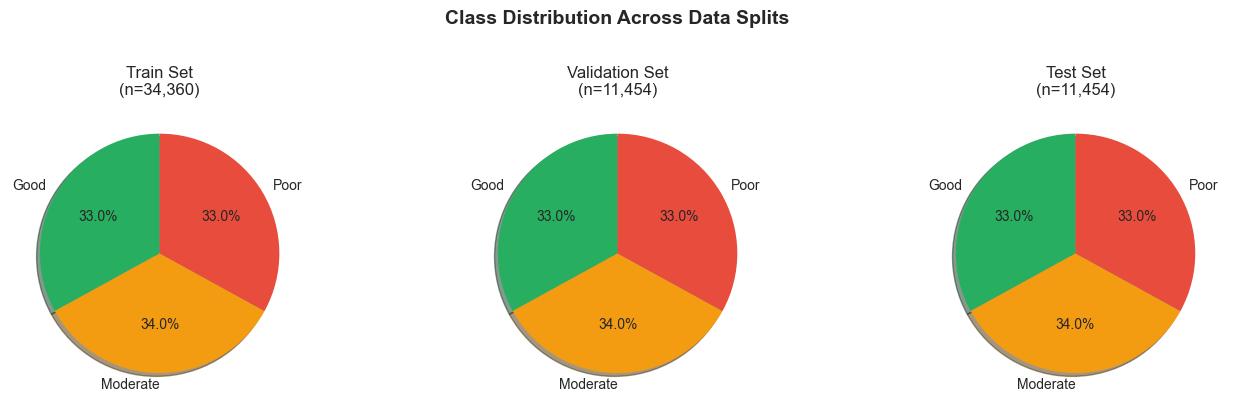

In [40]:
# Visualize class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]
colors = ['#27ae60', '#f39c12', '#e74c3c']
labels = ['Good', 'Moderate', 'Poor']

for ax, (name, y_data) in zip(axes, splits):
    counts = pd.Series(y_data).value_counts().sort_index()
    ax.pie(counts.values, labels=labels, autopct='%1.1f%%', 
           colors=colors, shadow=True, startangle=90)
    ax.set_title(f'{name} Set\n(n={len(y_data):,})')

plt.suptitle('Class Distribution Across Data Splits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Scaling

### 7.1 Scaling Strategy

- **StandardScaler**: Mean=0, Std=1 (important for neural networks)
- **Fitted on training data only** to prevent data leakage
- **Applied to all splits** using the same scaler

In [41]:
# Fit scaler on training data only
print(f"{'='*60}")
print(f"FEATURE SCALING")
print(f"{'='*60}")

scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train)

# Transform all splits
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FINAL_FEATURES, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=FINAL_FEATURES, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FINAL_FEATURES, index=X_test.index)

print(f"\n✅ StandardScaler fitted on training data")
print(f"   • Training set mean (first 5 features): {X_train_scaled.iloc[:, :5].mean().values}")
print(f"   • Training set std (first 5 features): {X_train_scaled.iloc[:, :5].std().values}")

FEATURE SCALING

✅ StandardScaler fitted on training data
   • Training set mean (first 5 features): [ 2.06793579e-17 -4.34266515e-17  6.78282938e-17  2.50220230e-17
 -2.93646881e-17]
   • Training set std (first 5 features): [1.00001455 1.00001455 1.00001455 1.00001455 1.00001455]


In [42]:
# Verify scaling
print(f"\n📊 Scaling Verification (Training Set):")
print(f"   Mean across all features: {X_train_scaled.mean().mean():.6f} (expected: ~0)")
print(f"   Std across all features: {X_train_scaled.std().mean():.6f} (expected: ~1)")

print(f"\n📊 Scaling Applied to Validation/Test:")
print(f"   Validation mean: {X_val_scaled.mean().mean():.6f}")
print(f"   Test mean: {X_test_scaled.mean().mean():.6f}")


📊 Scaling Verification (Training Set):
   Mean across all features: 0.000000 (expected: ~0)
   Std across all features: 1.000015 (expected: ~1)

📊 Scaling Applied to Validation/Test:
   Validation mean: -0.008637
   Test mean: 0.002189


## 8. Data Leakage Check

### 8.1 Verify No Target Information in Features

Critical check to ensure we're not using water quality parameters as features.

In [43]:
# Data leakage checks
print(f"{'='*60}")
print(f"DATA LEAKAGE VERIFICATION")
print(f"{'='*60}")

# Check 1: Target-related columns not in features
target_cols = ['chl_a', 'tss', 'secchi', 'chl_a_score', 'tss_score', 'secchi_score', 
               'wq_score', 'water_quality_class', 'water_quality_label']

leakage_found = False
print("\n1️⃣ Checking for target-related columns in features:")
for col in target_cols:
    if col in FINAL_FEATURES:
        print(f"   ❌ LEAKAGE: {col} found in features!")
        leakage_found = True
    else:
        print(f"   ✅ {col} NOT in features")

# Check 2: Scaler was fit only on training data
print("\n2️⃣ Scaling strategy:")
print("   ✅ StandardScaler fitted ONLY on training data")
print("   ✅ Same scaler applied to validation and test sets")

# Check 3: No index/identifier overlap issues
print("\n3️⃣ Index independence:")
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

train_val_overlap = len(train_idx.intersection(val_idx))
train_test_overlap = len(train_idx.intersection(test_idx))
val_test_overlap = len(val_idx.intersection(test_idx))

print(f"   Train-Validation overlap: {train_val_overlap} indices")
print(f"   Train-Test overlap: {train_test_overlap} indices")
print(f"   Validation-Test overlap: {val_test_overlap} indices")

if train_val_overlap + train_test_overlap + val_test_overlap == 0:
    print("   ✅ No index overlap between splits")
else:
    print("   ❌ Index overlap detected!")

if not leakage_found:
    print("\n🎉 No data leakage detected!")
else:
    print("\n⚠️ Data leakage detected - REVIEW FEATURE SELECTION!")

DATA LEAKAGE VERIFICATION

1️⃣ Checking for target-related columns in features:
   ✅ chl_a NOT in features
   ✅ tss NOT in features
   ✅ secchi NOT in features
   ✅ chl_a_score NOT in features
   ✅ tss_score NOT in features
   ✅ secchi_score NOT in features
   ✅ wq_score NOT in features
   ✅ water_quality_class NOT in features
   ✅ water_quality_label NOT in features

2️⃣ Scaling strategy:
   ✅ StandardScaler fitted ONLY on training data
   ✅ Same scaler applied to validation and test sets

3️⃣ Index independence:
   Train-Validation overlap: 0 indices
   Train-Test overlap: 0 indices
   Validation-Test overlap: 0 indices
   ✅ No index overlap between splits

🎉 No data leakage detected!


## 9. Save Preprocessed Data

### 9.1 Saving Strategy

Saving both scaled and unscaled versions for flexibility.

In [44]:
# Create output directory
os.makedirs('../processed_data', exist_ok=True)

print(f"{'='*60}")
print(f"SAVING PREPROCESSED DATA")
print(f"{'='*60}")

# Save scaled features
X_train_scaled.to_csv('../processed_data/X_train_scaled.csv', index=False)
X_val_scaled.to_csv('../processed_data/X_val_scaled.csv', index=False)
X_test_scaled.to_csv('../processed_data/X_test_scaled.csv', index=False)

# Save unscaled features (for tree-based models)
X_train.to_csv('../processed_data/X_train.csv', index=False)
X_val.to_csv('../processed_data/X_val.csv', index=False)
X_test.to_csv('../processed_data/X_test.csv', index=False)

# Save labels
pd.DataFrame({'label': y_train}).to_csv('../processed_data/y_train.csv', index=False)
pd.DataFrame({'label': y_val}).to_csv('../processed_data/y_val.csv', index=False)
pd.DataFrame({'label': y_test}).to_csv('../processed_data/y_test.csv', index=False)

# Save scaler
joblib.dump(scaler, '../processed_data/feature_scaler.pkl')

# Save feature list
with open('../processed_data/feature_names.txt', 'w') as f:
    for feat in FINAL_FEATURES:
        f.write(f"{feat}\n")

print("\n✅ Files saved (index=False):")
print("   📁 processed_data/")
print("      ├── X_train_scaled.csv")
print("      ├── X_val_scaled.csv")
print("      ├── X_test_scaled.csv")
print("      ├── X_train.csv")
print("      ├── X_val.csv")
print("      ├── X_test.csv")
print("      ├── y_train.csv")
print("      ├── y_val.csv")
print("      ├── y_test.csv")
print("      ├── feature_scaler.pkl")
print("      └── feature_names.txt")

SAVING PREPROCESSED DATA

✅ Files saved (index=False):
   📁 processed_data/
      ├── X_train_scaled.csv
      ├── X_val_scaled.csv
      ├── X_test_scaled.csv
      ├── X_train.csv
      ├── X_val.csv
      ├── X_test.csv
      ├── y_train.csv
      ├── y_val.csv
      ├── y_test.csv
      ├── feature_scaler.pkl
      └── feature_names.txt


In [45]:
# Also save the full processed dataframe with all columns for analysis notebooks
df.to_csv('../processed_data/full_dataset_processed.csv', index=False)
print("\n✅ Full processed dataset saved: processed_data/full_dataset_processed.csv")


✅ Full processed dataset saved: processed_data/full_dataset_processed.csv


## 10. Summary & Next Steps

In [46]:
# Final summary
print(f"\n{'='*60}")
print(f"✅ NOTEBOOK 03 COMPLETE")
print(f"{'='*60}")

print(f"""
📋 PREPROCESSING SUMMARY:

   Feature Engineering:
   • Created {len(SPECTRAL_INDICES)} spectral indices (NDWI, NDVI, NDTI, etc.)
   • Encoded {len(CATEGORICAL_FEATURES)} categorical features → {len(CATEGORICAL_ENCODED)} dummies
   • Encoded temporal features (cyclical month encoding)
   • Total features: {len(FINAL_FEATURES)}
   
   Data Splits:
   • Train: {len(X_train):,} samples (60%)
   • Validation: {len(X_val):,} samples (20%)
   • Test: {len(X_test):,} samples (20%)
   • Stratified by water quality class ✅
   
   Preprocessing:
   • StandardScaler fitted on training data only ✅
   • No data leakage verified ✅
   • Both scaled and unscaled data saved ✅
   
🔜 NEXT STEP: Proceed to Notebook 04 - Baseline Multiclass Model
   In that notebook, we will:
   1. Train Random Forest / XGBoost baseline
   2. Evaluate on validation set
   3. Analyze feature importance
   4. Save class probabilities for hybrid model
""")


✅ NOTEBOOK 03 COMPLETE

📋 PREPROCESSING SUMMARY:

   Feature Engineering:
   • Created 8 spectral indices (NDWI, NDVI, NDTI, etc.)
   • Encoded 2 categorical features → 7 dummies
   • Encoded temporal features (cyclical month encoding)
   • Total features: 34
   
   Data Splits:
   • Train: 34,360 samples (60%)
   • Validation: 11,454 samples (20%)
   • Test: 11,454 samples (20%)
   • Stratified by water quality class ✅
   
   Preprocessing:
   • StandardScaler fitted on training data only ✅
   • No data leakage verified ✅
   • Both scaled and unscaled data saved ✅
   
🔜 NEXT STEP: Proceed to Notebook 04 - Baseline Multiclass Model
   In that notebook, we will:
   1. Train Random Forest / XGBoost baseline
   2. Evaluate on validation set
   3. Analyze feature importance
   4. Save class probabilities for hybrid model

